# Projekt Zespołowy 2 — Zespół 10, "Sieci"

# Początkowa konfiguracja

W przypadku uruchomienia na Google Colab, dokonywane jest montowanie dysku i instalacja potrzebnych bibliotek. Jeżeli notatnik uruchamiany jest lokalnie, to wystarczy ustawienie ścieżki do katalogu głównego projektu. Poniższa komórka kodu zajmuje się tą konfiguracją

In [ ]:
try:
	from google.colab import drive
	import sys, os
	drive.mount('/content/drive')
	Project_Path = "drive/MyDrive/PZSP2-Z10/"
	sys.path.append(Project_Path+"src/")
	os.system(f"uv pip install -r {Project_Path}pyproject.toml")
except:
	Project_Path = "../../"

# Benchmark AMPL

### Ścieżka do plików AMPL

Własne pliki należy umieścić w folderze `src/AMPL/` bądź wpisać ścieżkę do nich poniżej. Zawarty w projekcie model ampl nadaje się do optymalizowania sieci w pełni połączonych, liczbę węzłów można własnoręczne podać zmieniając parametr "n" modelu.

In [ ]:
AMPL_Path = Project_Path+"src/AMPL/"
AMPL_Model = "PZSP2.mod"
AMPL_Data = "PZSP2.dat"

### Import bibliotek

In [ ]:
from pathlib import PurePath
from amplpy import ampl_notebook # type: ignore
import networkx as nx
import matplotlib.pyplot as plt
import time

### Konfiguracja solvera

In [ ]:
ampl = ampl_notebook(
    license_uuid="2ac42500-338f-4917-9b9e-8fdc1cc63912"
)

# pierwsze wczytanie modelu, po każdym kolejnym użyciu należy go zresetować, czym zajmuje się funkcja ampl_solve_fullmesh_task
ampl.read(str(PurePath(AMPL_Path+AMPL_Model)))
ampl.read_data(str(PurePath(AMPL_Path+AMPL_Data)))
ampl.option["solver"] = "cplex"

### Funkcje pomocniczne do wywoływania modelu AMP - rozwiązanie zadania oraz wizualizacja rozwiązania

In [ ]:
def ampl_solve_fullmesh_task(N):
  ampl.reset()

  # aby skorzystać z modelu AMPL należy go załadować na czysto za każdym razem
  ampl.read(str(PurePath(AMPL_Path+AMPL_Model)))
  ampl.read_data(str(PurePath(AMPL_Path+AMPL_Data)))

  nodes = ampl.get_parameter("n")
  nodes.set(N)

  start = time.perf_counter()
  ampl.solve()
  AMPL_time = time.perf_counter() - start

  assert ampl.solve_result == "solved"
  print(f"AMPL Solved in {AMPL_time:f}s")

  print(f"Total cost: {ampl.get_objective("total_cost").value()}")
  flow = ampl.get_variable("usage").get_values().to_pandas()
  print(f"Flow matrix:\n{flow}")
  encryption = ampl.get_variable("encrypted").get_values().to_pandas()
  print(f"Encrypted edges:\n{encryption}")
  bandwidth = ampl.get_data("{(i,j) in EDGES} sum {(k,l) in CONNECTIONS} (usage[i,j,k,l]+usage[j,i,k,l])").to_pandas()
  bandwidth.rename(columns={bandwidth.columns[0]: "bandwidth"}, inplace=True)
  print(f"Bandwidth usage:\n{bandwidth}")

  G = nx.Graph()
  G.add_nodes_from(range(1,N+1))
  G.add_weighted_edges_from([(i,j,bandwidth.at[(i,j),"bandwidth"]) for i in range(1,N+1) for j in range(1,N+1) if i<j])
  nx.set_edge_attributes(G, encryption.to_dict()['encrypted.val'], "encrypted")
  print(list(G.edges))
  print(nx.get_edge_attributes(G, "encrypted"))
  colors = [edge[2] for edge in G.edges.data("encrypted")]
  pos = nx.shell_layout(G)
  nx.draw(G, pos=pos, with_labels=True, font_weight='bold', edge_color=colors)
  nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=nx.get_edge_attributes(G, "weight"))
  plt.show()

# Algorytm Ewolucyjny

### Import bibliotek oraz przygotowanie podstawowych danych wejściowych

In [ ]:
from net_opt.core.constraints.bandwidth_limit import BandwidthLimit
from net_opt.core.constraints.demand import Demand
from net_opt.core.constraints.dependent_demand import DependentDemand
from net_opt.core.constraints.path_bandwidth_io_match import PathBandwidthIOMatch
from net_opt.core.constraints.path_edge_bandwidth_kirchhoff import PathEdgeBandwidthKirchhoff
from net_opt.core.constraints.path_transponder_bandwidth_at_least import PathTransponderBandwidthAtLeast
from net_opt.core.ea import EA, FastEA
from net_opt.core.mutations.base_mutation import Mutation
from net_opt.core.mutations.gene_mutation import GeneMutation
from net_opt.core.mutations.uniform_crossover import UniformCrossover
from net_opt.core.selections.tournament_selection import TournamentSelection
from net_opt.core.termination_conditions.base_termination_condition import TerminationCondition
from net_opt.core.termination_conditions.time_limit import TimeLimit
from net_opt.core.termination_conditions.max_iterations import MaxIterations
from net_opt.utils.visualisation import visualize_input_data, visualize_population_individual

import torch
from torch.distributions import Categorical
import pprint
import jaxtyping

pp = pprint.PrettyPrinter(indent=4)

### CUDA

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Running on {device} ---")
torch.set_default_device(device)

### Podstawowe dane wejściowe

In [ ]:
jaxtyping.config.update("jaxtyping_disable", True)

# testowa liczba węzłów, dla tej i paru większych wartości zaprezentujemy
# działanie narzędzia w kilku przykładowych eksperymentach
N=5

# zdefiniowanie transpenderów, razem z pojemnością rośnie cena
mock_transponder_capacities = torch.tensor([40.0, 100.0, 200.0, 400.0, 800.0])
mock_transponder_costs = torch.tensor([1.0, 3.0, 5.0, 9.0, 11.0])
T = mock_transponder_capacities.shape[0]

max_bandwidth=96
#path_dist = Categorical(torch.ones(max(max_bandwidth//(N*N), 2)))
mu = max_bandwidth//2
N_pairs = N*(N-1)//2
skip = mu//N_pairs
p = mu/N_pairs - skip
probs = [0]*(skip) + [1-p] + [p]
path_dist = Categorical(torch.tensor(probs))

trans_dist = Categorical(torch.ones(max_bandwidth//T))

# dane konfiguracyjne do samego algorytmu, siły mutacji, rozmiar populacji, ilość iteracji itp
mutation_config: list[Mutation] =[
    GeneMutation(
        path_edge_bandwidth_usage_mut_proba=0.5,
        path_transponder_assignment_mut_proba=0.5
    ),
    UniformCrossover(
        path_edge_bandwidth_usage_cross_proba=0.5,
        path_transponder_assignment_cross_proba=0.5
    )
]
selection_config = TournamentSelection(k=3)
termination_config : list[TerminationCondition] = [
    MaxIterations(iterations=10000),
]

ea_config = EA(
    show_vizualisation_every_n_iter=1000,
    population_size=1000,
    elite_size=50,
    path_edge_bandwidth_usage_init_distribution=path_dist,
    path_transponder_assignment_init_distribution=trans_dist,
    constraints=[
        PathBandwidthIOMatch(),
        PathEdgeBandwidthKirchhoff(),
        PathTransponderBandwidthAtLeast(),
        Demand(),
        BandwidthLimit(),
        ],
    termination_conditions=termination_config,
    selection_method=selection_config,
    mutation_methods=mutation_config,
    global_constraint_weight=10000,
	device=device
)

### Funkcje pomocnicze

In [ ]:
from typing import List, Tuple

def ea_summarize_run():
  print("\n--- EA Run Finished ---")
  print(f"Total iterations: {ea_instance._iteration_n}")
  visualize_population_individual(ea_instance._population, ea_instance._transponder_capacities)
  dict_constraint_name_scores ={
  ea_instance.constraints[i].readable_name: ea_instance._lowest_penalty_constraint_scores[i]
  for i in range(len(ea_instance._constraint_scores))
  }
  print("-"*40)
  print(f"it: {ea_instance._iteration_n}")
  print(f"lowest_penalty: {ea_instance._lowest_penalty}")
  print("lowest_penalty_constraint_scores:")
  pp.pprint(dict_constraint_name_scores)
  print(f"lowest_transponder_cost: {ea_instance._lowest_transponder_cost}")


def set_connections(N, connection_list: List[Tuple[int, int]]):
  neigh_matrix = torch.zeros((N, N), dtype=torch.bool)
  for connection in connection_list:
    a, b = connection
    neigh_matrix[a-1][b-1] = neigh_matrix[b-1][a-1] = True
  return neigh_matrix

# Przykładowe eksperymenty

## Fullmesh z 5 węzłami

### Rozwiązanie modelem AMPL

In [ ]:
N = 5
ampl_solve_fullmesh_task(N)

### Rozwiązanie algorytmem ewolucyjnym

In [ ]:
N = 5 # liczba węzłów w sieci fullmesh
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool) # macierz sąsiedztwa, tu zachodzi zdefiniowanie struktury sieci
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1) # zapotrzebowanie w sieci

### Wizualizacja danych wejściowych

In [ ]:
visualize_input_data(
    mock_neigh_matrix,
    mock_demand,
    mock_transponder_costs,
    mock_transponder_capacities
)

### Wykonanie eksperymentu

In [ ]:
jaxtyping.config.update("jaxtyping_disable", True)

# istnieją 2 opcje wywołania algorytmu ewolucyjnego. Wersja użyta w przykładowych
# eksperymentach pozwala śledzić działanie algorytmu. W celu szybszego uzyskania wyników
# i tylko porównania końcowego zalecamy użyć ea_fast
ea_instance = ea_config
ea_instance.run(
    neigh_matrix=mock_neigh_matrix,
    demand=mock_demand,
    transponder_costs=mock_transponder_costs,
    transponder_capacities=mock_transponder_capacities
)

ea_summarize_run()

## Fullmesh z 10 węzłami

### Rozwiązanie modelem AMPL

In [ ]:
N = 10
ampl_solve_fullmesh_task(N)

### Rozwiązanie algorytmem ewolucyjnym

In [ ]:
N = 10 # liczba węzłów w sieci fullmesh
T = 5 # liczba rodzaji transponderów
mock_neigh_matrix = ~torch.eye(N, dtype=torch.bool) # macierz sąsiedztwa, tu zachodzi zdefiniowanie struktury sieci
mock_demand = torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1)

### Wizualizacja danych wejściowych

In [ ]:
visualize_input_data(
    mock_neigh_matrix,
    mock_demand,
    mock_transponder_costs,
    mock_transponder_capacities
)

### Wykonanie eksperymentu

In [ ]:
jaxtyping.config.update("jaxtyping_disable", True)

# istnieją 2 opcje wywołania algorytmu ewolucyjnego. Wersja użyta w przykładowych
# eksperymentach pozwala śledzić działanie algorytmu. W celu szybszego uzyskania wyników
# i tylko porównania końcowego zalecamy użyć ea_fast
ea_instance = ea_config
ea_instance.run(
    neigh_matrix=mock_neigh_matrix,
    demand=mock_demand,
    transponder_costs=mock_transponder_costs,
    transponder_capacities=mock_transponder_capacities
)

ea_summarize_run()

## Przykład sieci rzeczywistej - atlana
wszystkie przykłady sieci rzeczywistych wykorzystywane w tych eksperymentach pochodzą ze strony https://sndlib.put.poznan.pl/home.action.

Poniżej znajduje się diagram sieci pozyskany w wcześniej wymienionej strony:
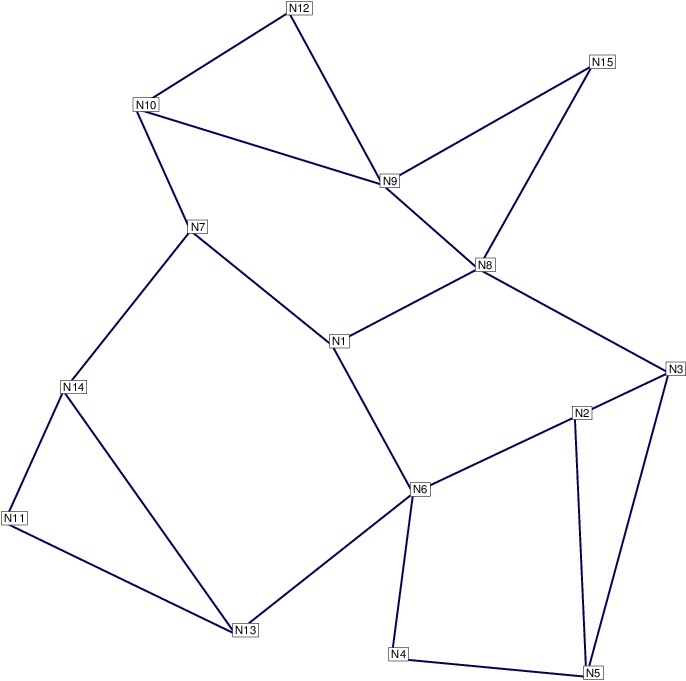

### Rozwiązanie modelem AMPL

In [ ]:
# UWAGA: 20 jest już dużą liczbą węzłów dla tych modeli. AMPL dobrze radzi sobie
# z podaniem rozwiązania, natomiast wizualizacje grafowe będą znacznie mniej czytelne
# także dla wszystkich większych wartości N

# AMPL MODEL CURRENTLY UNFIT TO SOLVE NON-FULLMESHTASKS

# N = 20
# ampl_solve_fullmesh_task(N)

### Rozwiązanie algorytmem ewolucyjnym

In [ ]:
N = 15 # liczba węzłów w sieci fullmesh

# jak widać połączenia w sieci można łatwo zdefiniować bezpośrednio w kodzie
connection_list = [(1, 6), (1, 7), (1, 8), (2, 3), (2, 5), (2, 6),
                   (3, 5), (3, 8), (4, 5), (4, 6), (6, 13),(7, 10),
                   (7, 14), (8, 9), (8, 15), (9, 10), (9, 12), (9, 15),
                   (10, 12), (11, 13), (11, 14), (13, 14)]

mock_neigh_matrix = set_connections(N, connection_list)

mock_demand = torch.mul(torch.triu(torch.full((N, N), 44000, dtype=torch.float), diagonal=1), mock_neigh_matrix)

print(mock_neigh_matrix)

### Wizualizacja danych wejściowych

In [ ]:
visualize_input_data(
    mock_neigh_matrix,
    mock_demand,
    mock_transponder_costs,
    mock_transponder_capacities
)

### Wykonanie eksperymentu

In [ ]:
jaxtyping.config.update("jaxtyping_disable", True)

# istnieją 2 opcje wywołania algorytmu ewolucyjnego. Wersja użyta w przykładowych
# eksperymentach pozwala śledzić działanie algorytmu. W celu szybszego uzyskania wyników
# i tylko porównania końcowego zalecamy użyć ea_fast
ea_instance = ea_config
ea_instance.run(
    neigh_matrix=mock_neigh_matrix,
    demand=mock_demand,
    transponder_costs=mock_transponder_costs,
    transponder_capacities=mock_transponder_capacities
)

ea_summarize_run()